In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [34]:
df = pd.read_csv("Books_Data_Clean.csv")
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [35]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [36]:
df = df[df["Publishing Year"] > 1800]
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000
mean,537.032381,1989.703810,4.009419,94723.344762,1855.259381,844.808280,4.889524,614.719048,9709.083810
std,309.470443,34.076973,0.247090,31523.050620,3948.841694,2266.203156,3.572709,370.425543,15365.222464
min,0.000000,1812.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,269.250000,1986.000000,3.850000,70285.500000,370.882500,0.000000,1.990000,289.250000,577.500000
50%,538.500000,2003.000000,4.020000,88940.000000,809.745000,276.609000,3.990000,600.500000,3942.000000
75%,804.750000,2010.000000,4.170000,113523.750000,1486.025000,721.180500,7.102500,937.750000,5346.000000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [37]:
df.isna().sum()

index                   0
Publishing Year         0
Book Name              21
Author                  0
language_code          50
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [41]:
df.dropna(subset="Book Name", inplace=True)
df.isna().sum()

index                   0
Publishing Year         0
Book Name               0
Author                  0
language_code          48
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [43]:
df.duplicated().sum()
df.nunique()

index                  1029
Publishing Year         131
Book Name              1027
Author                  708
language_code             8
Author_Rating             4
Book_average_rating     133
Book_ratings_count     1023
genre                     4
gross sales             798
publisher revenue       587
sale price              145
sales rank              840
Publisher                 9
units sold              479
dtype: int64

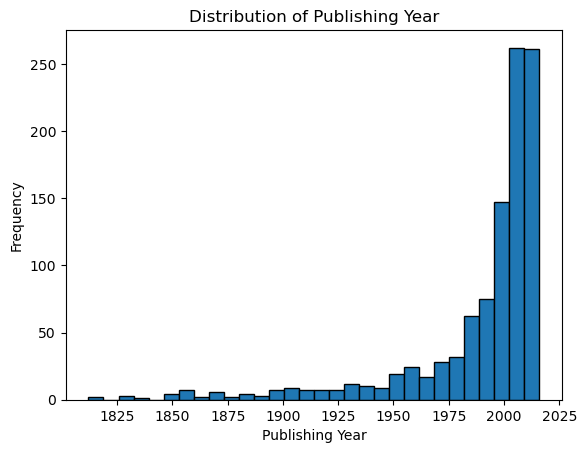

In [48]:
plt.hist(df["Publishing Year"] , bins=30, edgecolor="black")
plt.xlabel("Publishing Year")
plt.ylabel("Frequency")
plt.title("Distribution of Publishing Year")
plt.show()


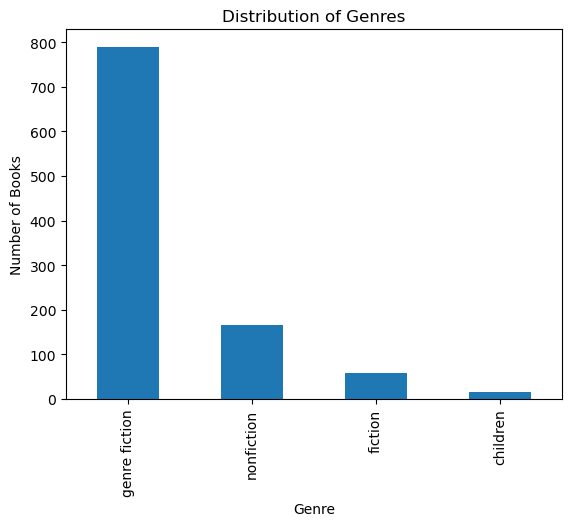

In [50]:
df["genre"].value_counts().plot(kind="bar")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.title("Distribution of Genres")
plt.show()

In [60]:
df.apply(lambda x: x if len(x) > 3 else None).groupby("Author")["Book_average_rating"].mean().sort_values(ascending=False)


Author
Bill Watterson                  4.650
Bill Watterson, G.B. Trudeau    4.610
J.R.R. Tolkien                  4.590
George R.R. Martin              4.560
Sarah J. Maas                   4.526
                                ...  
Audrey Niffenegger              3.230
Herman Koch, Sam Garrett        3.220
Stephen Crane                   3.210
P.D. James                      3.210
Sue Monk Kidd                   3.100
Name: Book_average_rating, Length: 708, dtype: float64

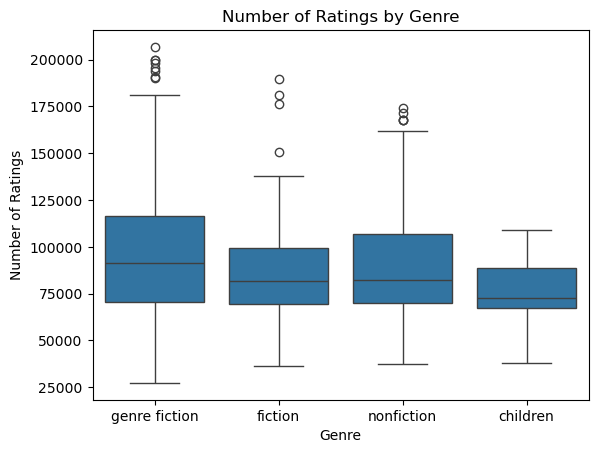

In [63]:
sns.boxplot(x="genre", y="Book_ratings_count", data=df)
plt.xlabel("Genre")
plt.ylabel("Number of Ratings")
plt.title("Number of Ratings by Genre")
plt.show()

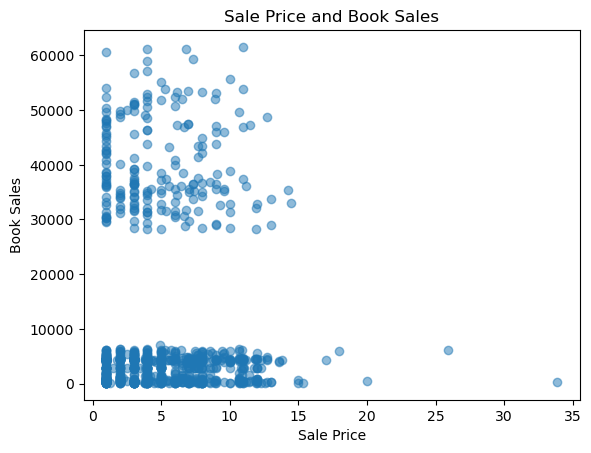

In [66]:
plt.scatter(df["sale price"], df["units sold"], alpha=0.5)
plt.xlabel("Sale Price")
plt.ylabel("Book Sales")
plt.title("Sale Price and Book Sales")
plt.show()

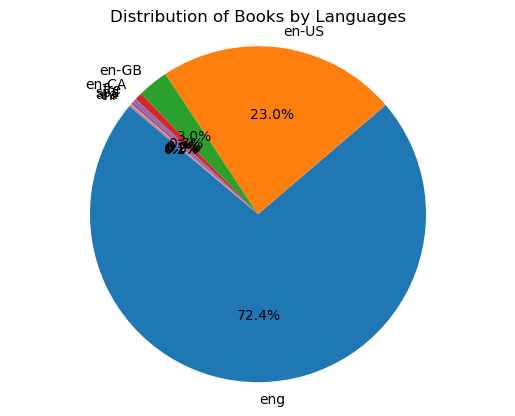

In [70]:
language_counts = df["language_code"].value_counts()
plt.pie(language_counts, labels=language_counts.index, autopct="%1.1f%%", startangle=140)
plt.axis("equal")
plt.title("Distribution of Books by Languages")
plt.show()

In [71]:
df.groupby("Publisher ")["units sold"].sum().sort_values(ascending=False).head(10)

Publisher 
Amazon Digital Services,  Inc.          5880004
Random House LLC                        1313958
Penguin Group (USA) LLC                  913876
HarperCollins Publishers                 552401
Hachette Book Group                      524675
Simon and Schuster Digital Sales Inc     501928
Macmillan                                334929
HarperCollins Publishing                  44358
HarperCollins Christian Publishing        41527
Name: units sold, dtype: int64

In [74]:
df.groupby("Author_Rating")["Book_ratings_count"].mean().sort_values(ascending=False)

Author_Rating
Intermediate    101449.635762
Famous           98529.102041
Novice           86667.758621
Excellent        83283.994236
Name: Book_ratings_count, dtype: float64

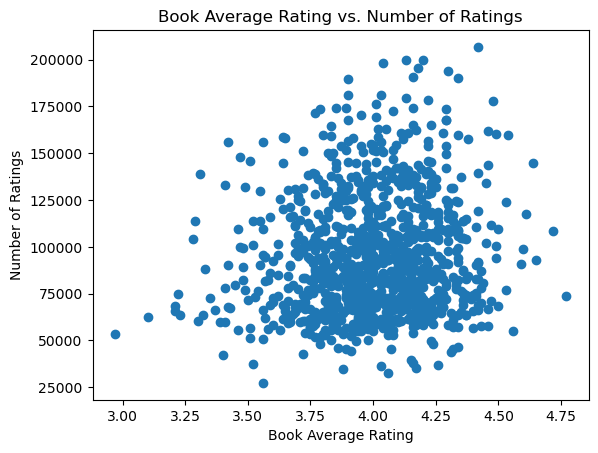

In [75]:
plt.scatter(df["Book_average_rating"], df["Book_ratings_count"])
plt.xlabel("Book Average Rating")
plt.ylabel("Number of Ratings")
plt.title("Book Average Rating vs. Number of Ratings")
plt.show()

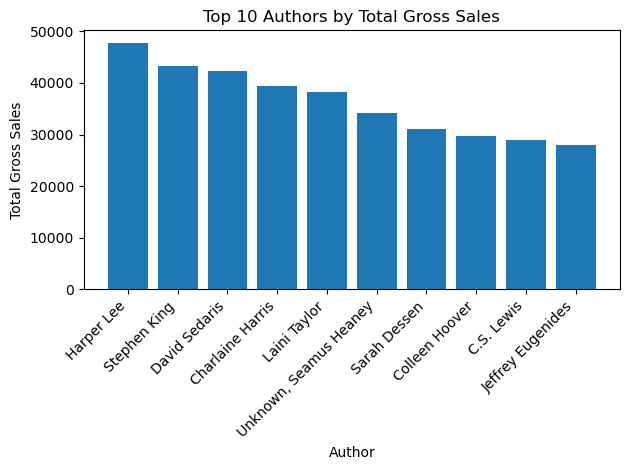

In [84]:
total_gross_sales_by_author = df.groupby("Author")["gross sales"].sum()
top_10_authors = total_gross_sales_by_author.sort_values(ascending=False).head(10)
plt.bar(top_10_authors.index, top_10_authors.values)
plt.xlabel("Author")
plt.ylabel("Total Gross Sales")
plt.title("Top 10 Authors by Total Gross Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


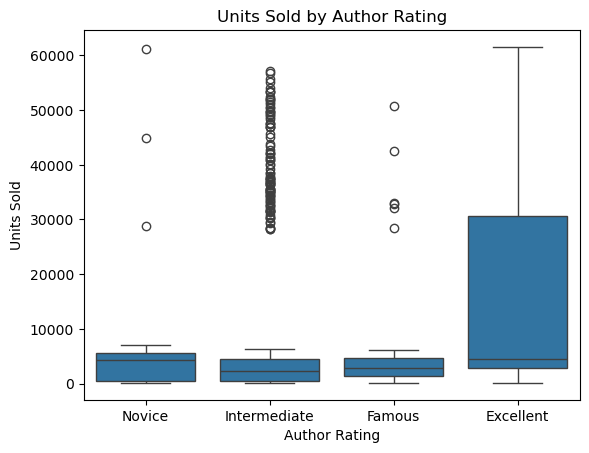

In [85]:
sns.boxplot(x="Author_Rating", y="units sold", data=df)
plt.xlabel("Author Rating")
plt.ylabel("Units Sold")
plt.title("Units Sold by Author Rating")
plt.show()

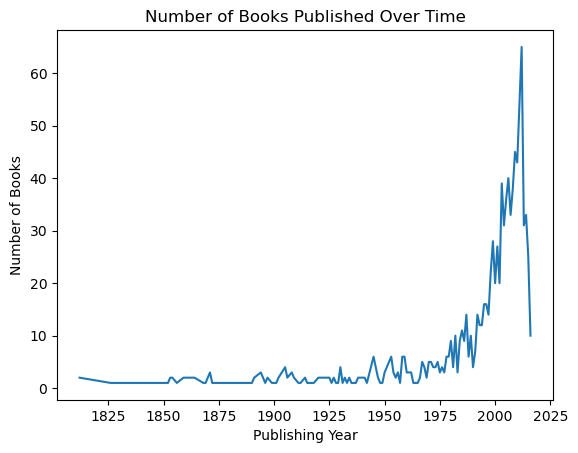

In [86]:
df.groupby("Publishing Year")["units sold"].count().plot(kind="line")
plt.xlabel("Publishing Year")
plt.ylabel("Number of Books")
plt.title("Number of Books Published Over Time")
plt.show()